<h1> Exploratory Data Analysis - HNTS-MRG </h1>

This code uses the dataset from Cybele

In [1]:
import os
import glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


<h3>Getting Data</h3>

In [ ]:
# Use of ChatGPT for help with loading data
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"

case_dirs = sorted(glob.glob(os.path.join(base_dir, "*")))
data = []

for case_dir in case_dirs:
    case_id = os.path.basename(case_dir) 
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        data.append({"case_id": case_id, "image": image_path, "label": label_path})
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(data)} samples in train-data")
print(data[0])

Found 130 samples in train-data
{'case_id': '10', 'image': '/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_T2.nii.gz', 'label': '/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_mask.nii.gz'}


In [4]:
test_base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/test"

test_case_dirs = sorted(glob.glob(os.path.join(test_base_dir, "*")))
test_data = []

for test_case_dir in test_case_dirs:
    test_case_id = os.path.basename(test_case_dir)  # e.g., "2"
    test_image_path = os.path.join(test_case_dir, "preRT", f"{test_case_id}_preRT_T2.nii.gz")
    test_label_path = os.path.join(test_case_dir, "preRT", f"{test_case_id}_preRT_mask.nii.gz")

    if os.path.exists(test_image_path) and os.path.exists(test_label_path):
        test_data.append({"image": test_image_path, "label": test_label_path})
    else:
        print(f"Missing data for case {test_case_id}, skipping.")

print(f"Found {len(test_data)} samples in test-data")
print(test_data[0])

Found 20 samples in test-data
{'image': '/datasets/tdt4265/mic/open/HNTS-MRG/test/104/preRT/104_preRT_T2.nii.gz', 'label': '/datasets/tdt4265/mic/open/HNTS-MRG/test/104/preRT/104_preRT_mask.nii.gz'}


<h3>Visualization of Data</h3>

In [ ]:
def load_nifti(filepath): # load the nifti MRI file and return as np array
    img = nib.load(filepath)
    data = img.get_fdata()
    return data, img.affine, img.header


In [ ]:
# Help from chatGPT for overlay
def plot_mri_and_mask(image, mask, slice_idx=None, title=None):
    if slice_idx is None:
        slice_idx = image.shape[2] // 2  # Middle slice

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image[:, :, slice_idx], cmap="gray")
    axes[0].set_title("MRI Image (Slice {})".format(slice_idx))

    axes[1].imshow(image[:, :, slice_idx], cmap="gray")
    axes[1].imshow(mask[:, :, slice_idx], alpha=0.5, cmap="Reds")
    axes[1].set_title("MRI + Tumor Mask (Slice {})".format(slice_idx))

    for ax in axes:
        ax.axis("off")

    if title:
        plt.suptitle(title, fontsize=16)

    plt.show()

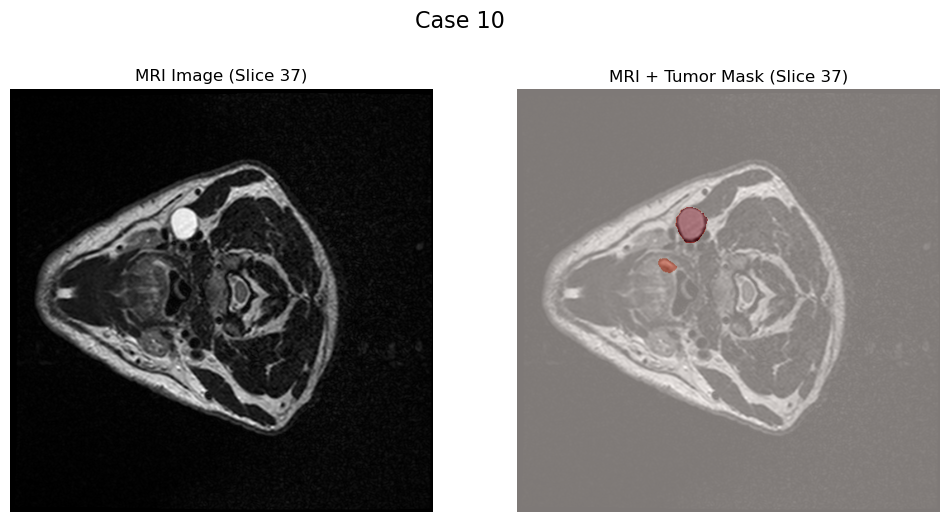

In [ ]:
# Load first sample
sample = data[0]
image, img_aff, img_head = load_nifti(sample["image"])
mask, mask_aff, mask_head = load_nifti(sample["label"])

plot_mri_and_mask(image, mask, title=f"Case {sample['case_id']}")


<h3>Image shape, tumor sizes and class balance</h3>

In [ ]:
stats = []

for d in data:
    img, _, _ = load_nifti(d["image"])
    mask, _, _ = load_nifti(d["label"])

    tumor_voxels = np.sum(mask>0)
    total_voxels = np.prod(mask.shape)
    tumor_volume = tumor_voxels / total_voxels

    stats.append({
        "case_id": d["case_id"],
        "image_shape": img.shape,
        "tumor_voxels": tumor_voxels,
        "tumor_volume_percent": tumor_volume*100,
    })

df_stats = pd.DataFrame(stats)
display(df_stats)


,case_id,image_shape,tumor_voxels,tumor_volume_percent
0,10,"(512, 512, 75)",26867,0.136653
1,101,"(512, 512, 82)",25550,0.118860
2,103,"(512, 512, 74)",45298,0.233511
3,107,"(512, 512, 65)",5660,0.033217
4,109,"(512, 512, 67)",20569,0.117111
...,...,...,...,...
125,93,"(512, 512, 74)",18870,0.097275
126,94,"(512, 512, 77)",18444,0.091374
127,95,"(512, 512, 71)",58843,0.316152
128,96,"(512, 512, 69)",4975,0.027505


In [ ]:
shapes = []
for sample in data:
    image, _, _ = load_nifti(sample["image"])
    shapes.append(image.shape)

shape_array = np.array(shapes)

for dim in range(3):
    print(f"Dimension {dim} (Axis {['Height','Width','Depth'][dim]}): "
          f"Min = {shape_array[:, dim].min()}, Max = {shape_array[:, dim].max()}, Mean = {shape_array[:, dim].mean()}")

Dimension 0 (Axis Height): Min = 512, Max = 640, Mean = 522.9538461538461
Dimension 1 (Axis Width): Min = 480, Max = 640, Mean = 522.4615384615385
Dimension 2 (Axis Depth): Min = 57, Max = 162, Mean = 84.79230769230769


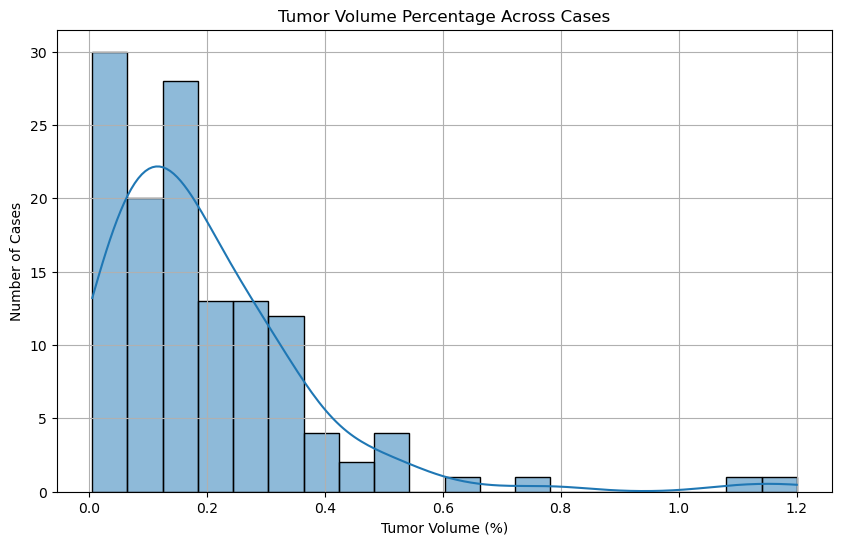

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stats["tumor_volume_percent"], kde=True, bins=20)
plt.title("Tumor Volume Percentage Across Cases")
plt.xlabel("Tumor Volume (%)")
plt.ylabel("Number of Cases")
plt.grid(True)
plt.show()

We observe that the tumors are quite small in general, taking up only about 0.2 % of the volume in most cases.
Thus, we have a very high class imbalance, where the background dominates, while the tumors only take up a small portion of space

Further, we see that there are a few cases where the tumors take up a significantly larger volume, with about 1.2 %, but this is in rare occations.

Because of the class imbalance, I need to develop a model which handles this. Some form of DICE which measures overlap between predicted and ground-truth segmentations might thus be good.

It is also quite a lot of cases (30) which have very small tumors, but still larger than 0 %.

<h3>Voxel (3D-pixel) Intensity and Spacing</h3>

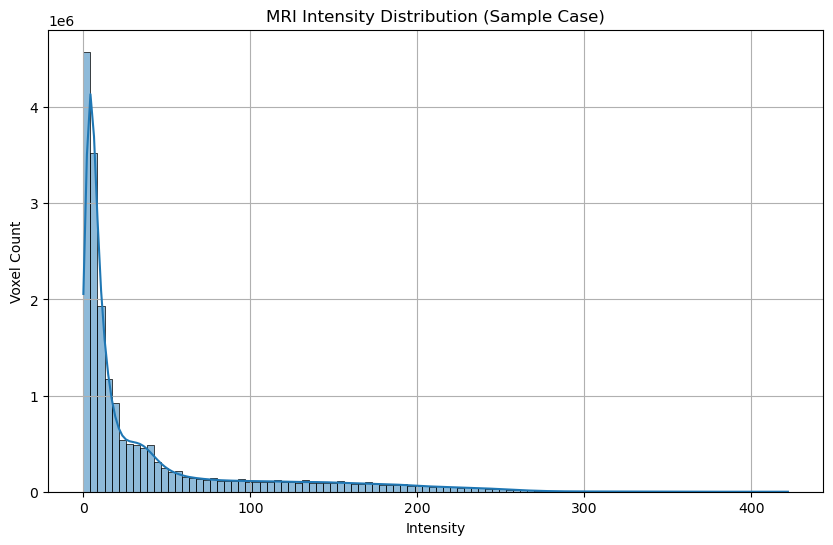

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(image.flatten(), bins=100, kde=True)
plt.title("MRI Intensity Distribution (Sample Case)")
plt.xlabel("Intensity")
plt.ylabel("Voxel Count")
plt.grid(True)
plt.show()

Most voxel intensities are from 0-50, which makes sense for an MRI.

There are however some large outliers at about 400, which might possibly harm the model. Therefore I need to normalize the data during preprosessing.

The model I develop will segment each voxel.

In [ ]:
# Voxel spacing (physical size of each voxel in mm)
spacings = []

for case_dir in case_dirs:
    image_path = os.path.join(case_dir, "preRT", f"{os.path.basename(case_dir)}_preRT_T2.nii.gz")
    if os.path.exists(image_path):
        img = nib.load(image_path)
        spacing = img.header.get_zooms() # (x, y, z)
        spacings.append(spacing)

spacings = np.array(spacings)
print("Spacing Statistics:")
print(f"  Mean: {np.mean(spacings, axis=0)}")
print(f"  Std: {np.std(spacings, axis=0)}")
print(f"  Min: {np.min(spacings, axis=0)}")
print(f"  Max: {np.max(spacings, axis=0)}")

Spacing Statistics:
  Mean: [0.5854167 0.5854167 1.8223073]
  Std: [0.18741582 0.18741582 0.35328516]
  Min: [0.4 0.4 1. ]
  Max: [0.9848485 0.9848485 2.5      ]


A CNN will treat each case it gets the same (equally spaced) which will distort the MRI. The CNN will treat each voxel as 1x1x1, when in reality it is more likely to be 0.6x0.6x1.8

Therefore it will be important to normalize the voxel spacing as well.